In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

In [19]:

weights = torch.randn(2, 1, requires_grad=True)
bias = torch.zeros(1, requires_grad=True)

In [20]:
class MomentumOptimizer:

    def __init__(self, lr=0.01, momentum=0.9):

        self.lr = lr

        self.momentum = momentum

        self.velocity = {}

    def step(self, params):

        for i, param in enumerate(params):

            if i not in self.velocity:

                self.velocity[i] = torch.zeros_like(param)

            self.velocity[i] = (
                self.momentum * self.velocity[i]
                - self.lr * param.grad
            )

            param.data += self.velocity[i]

In [21]:
class RMSPropOptimizer:

    def __init__(self, lr=0.001, beta=0.9, epsilon=1e-8):

        self.lr = lr

        self.beta = beta

        self.epsilon = epsilon

        self.cache = {}

    def step(self, params):

        for i, param in enumerate(params):

            if i not in self.cache:

                self.cache[i] = torch.zeros_like(param)

            self.cache[i] = (
                self.beta * self.cache[i]
                + (1 - self.beta) * param.grad**2
            )

            param.data -= (
                self.lr * param.grad
                / (torch.sqrt(self.cache[i]) + self.epsilon)
            )

In [22]:
class AdamOptimizer:

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):

        self.lr = lr

        self.beta1 = beta1

        self.beta2 = beta2

        self.epsilon = epsilon

        self.m = {}

        self.v = {}

        self.t = 0

    def step(self, params):

        self.t += 1

        for i, param in enumerate(params):

            if i not in self.m:

                self.m[i] = torch.zeros_like(param)

                self.v[i] = torch.zeros_like(param)

            self.m[i] = (
                                self.beta1 * self.m[i]
                + (1 - self.beta1) * param.grad
            )

            self.v[i] = (
                self.beta2 * self.v[i]
                + (1 - self.beta2) * param.grad**2
            )

            m_hat = self.m[i] / (1 - self.beta1**self.t)

            v_hat = self.v[i] / (1 - self.beta2**self.t)

            param.data -= (
                self.lr * m_hat
                / (torch.sqrt(v_hat) + self.epsilon)
            )

In [23]:
X = torch.randn(200,2)

y = (X[:,0]**2 + X[:,1] > 0).float().view(-1,1)

In [24]:
loss_function = torch.nn.MSELoss()

In [25]:
optimizer = AdamOptimizer(lr=0.01)

loss_history = []

for epoch in range(100):

    prediction = X @ weights + bias

    loss = loss_function(prediction, y)

    loss.backward()

    optimizer.step([weights, bias])

    loss_history.append(loss.item())

    weights.grad.zero_()

    bias.grad.zero_()

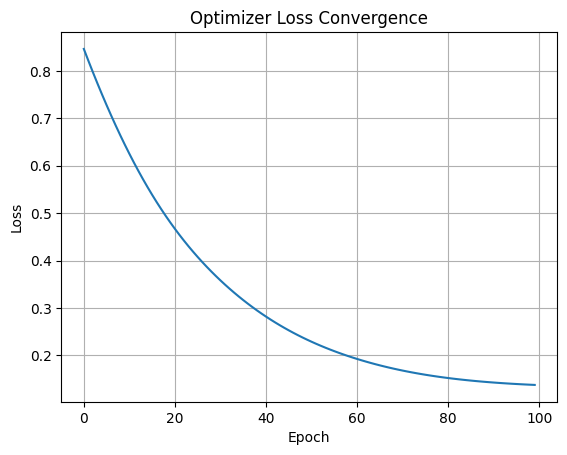

In [26]:
plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Optimizer Loss Convergence")

plt.grid(True)

plt.show()

